In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("llmdata.csv")
df.isnull().mean().sort_values(ascending=False)
df.corr(numeric_only=True)["blended_cost_usd_per_1m"].sort_values(ascending=False)

blended_cost_usd_per_1m     1.000000
output_cost_usd_per_1m      0.997997
input_cost_usd_per_1m       0.996299
arena_votes                 0.342320
composite_benchmark         0.296072
aa_coding_index             0.267614
scicode                     0.261588
chatbot_arena_elo           0.237256
mmlu_pro                    0.207958
gpqa_diamond                0.202544
time_to_first_token_s       0.187876
math_500                    0.133330
aa_math_index               0.131872
humanitys_last_exam         0.128854
livecodebench               0.110553
aime_2025                   0.104796
aa_intelligence_index       0.084565
elo_benchmark_blend         0.077809
time_to_first_answer_s      0.066436
parameter_count             0.059757
intelligence_per_dollar    -0.130652
speed_per_dollar           -0.133025
release_year               -0.145169
output_tokens_per_second   -0.200397
is_open_source             -0.217249
arena_elo_ci95             -0.220243
price_performance_ratio    -0.321920
N

MSE: 7.25821316478053
R²: 0.43299523827018127


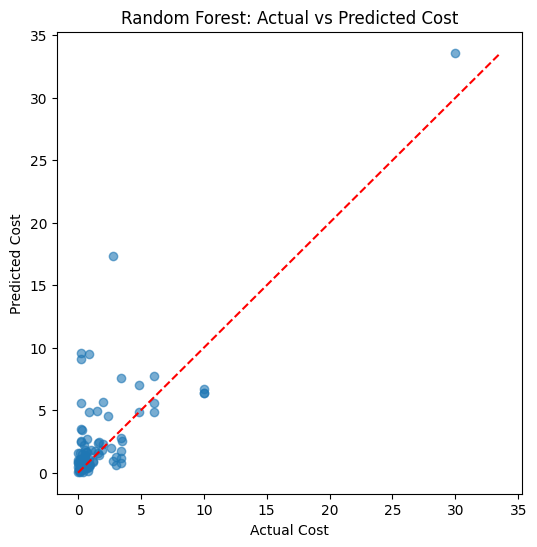

Test size: 95


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

cols = [
    "arena_votes",
    "composite_benchmark",
    "aa_coding_index",
    "scicode",
    "chatbot_arena_elo",
    #"mmlu_pro",
    #"gpqa_diamond",
    #"time_to_first_token_s",
    #"math_500",
    "output_tokens_per_second",
    "is_open_source",
    "release_year",
    "parameter_count",
]

target = "blended_cost_usd_per_1m"

df_clean = df[cols + [target]].dropna(subset=[target])

X = df_clean[cols].copy()
y = df_clean[target].copy()

X["is_open_source"] = X["is_open_source"].astype(int)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Random Forest: Actual vs Predicted Cost")

min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())

plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.show()

print("Test size:", len(y_test))